# Notebook for experimenting with RDKit

In [2]:
import rdkit
from rdkit import Chem


## A simple ethanol molecule and inspecting its properties:

['__module__', '__doc__', '__reduce__', '__instance_size__', '__init__', '__copy__', '__deepcopy__', 'GetNumAtoms', 'GetNumHeavyAtoms', 'GetAtomWithIdx', 'GetNumBonds', 'GetBondWithIdx', 'GetNumConformers', 'AddConformer', 'GetConformer', 'GetConformers', 'RemoveAllConformers', 'RemoveConformer', 'GetBondBetweenAtoms', 'HasQuery', 'HasSubstructMatch', 'GetSubstructMatch', 'GetSubstructMatches', 'SetProp', 'SetDoubleProp', 'SetIntProp', 'SetUnsignedProp', 'SetBoolProp', 'HasProp', 'GetProp', 'GetDoubleProp', 'GetIntProp', 'GetUnsignedProp', 'GetBoolProp', 'ClearProp', 'ClearComputedProps', 'UpdatePropertyCache', 'NeedsUpdatePropertyCache', 'ClearPropertyCache', 'GetStereoGroups', 'GetPropNames', 'GetPropsAsDict', 'GetAromaticAtoms', 'GetAtomsMatchingQuery', '__safe_for_unpickling__', '__getstate_manages_dict__', '__getinitargs__', '__getstate__', '__setstate__', 'Debug', 'ToBinary', 'GetRingInfo', 'GetAtoms', 'GetBonds', '_repr_png_', '_repr_svg_', '_repr_html_', '__GetSubstructMatch', 

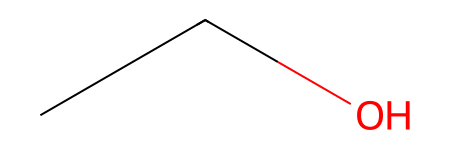

In [9]:
ethanol = Chem.MolFromSmiles('CCO')

print(ethanol.__dir__())

print("Atom count:", ethanol.GetNumAtoms())

ethanol_num_conformers = ethanol.GetNumConformers()

print(f"Number of conformers: {ethanol_num_conformers}")

print("Has 3D coordinates?",  ethanol_num_conformers> 0)

ethanol

In [ ]:
atom = ethanol.GetAtomWithIdx(0)
print("Atom element:", atom.GetSymbol())

ethanol_conformer = ethanol.GetConformer()
ethanol_conformer.GetAtomPosition(0)

## We get a Value Error here because there is no 3D spatial information in the molecule yet.

Atom element: C


ValueError: Bad Conformer Id

## Now giving the molecule a 3D structure

In [15]:
ethanol_3d = Chem.Mol(ethanol)
print("Atom count before adding H's:", ethanol_3d.GetNumAtoms())

# Explicitly add Hydrogens
ethanol_3d = Chem.AddHs(ethanol_3d)
print("Atom count after adding H's:", ethanol_3d.GetNumAtoms())

from rdkit.Chem import AllChem

# Embed molecule to get spatial information
AllChem.EmbedMolecule(ethanol_3d, randomSeed=42)

print("Has 3D coordinates now?", ethanol_3d.GetNumConformers() > 0)

# Extract and print the actual XYZ coordinates of the first atom
pos = ethanol_3d.GetConformer().GetAtomPosition(0)
print(f"Atom 0 ({ethanol_3d.GetAtomWithIdx(0).GetSymbol()}) 3D Position: X={pos.x:.3f}, Y={pos.y:.3f}, Z={pos.z:.3f}")

Atom count before adding H's: 3
Atom count after adding H's: 9
Has 3D coordinates now? True
Atom 0 (C) 3D Position: X=-0.953, Y=0.048, Z=0.042


## Visualizing the 3D molecule

In [20]:
import py3Dmol

# Convert RDKit molecule object to a string format py3Dmol understands
ethanol_block = Chem.MolToMolBlock(ethanol_3d)

# Create the interactive 3D viewer canvas
viewer = py3Dmol.view(width=400, height=400)
viewer.addModel(ethanol_block, "ethanol")

# Style the visualization (stick representation shows bonds clearly)
viewer.setStyle({'stick': {'radius': 0.12}, 'sphere': {'scale': 0.25}})

viewer.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.